# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [2]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [3]:
aviation_df = pd.read_csv('cleaned_aviation_data.csv', index_col=0, encoding='latin1')

## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [ ]:
small_plane_df = aviation_df[aviation_df["Total.Onboard"] < 20]
large_plane_df = aviation_df[aviation_df["Total.Onboard"] >= 20]

small_plane_df.head()

,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,...,Total.Uninjured,Weather.Condition,Report.Status,Publication.Date,Total.Onboard,Fatal.Serious.Count,Fatal.Serious.Rate,Aircraft.Damage,Make_Model,Make.Model
Investigation.Type,,,,,,,,,,,,,,,,,,,,,
Accident,DCA87MA018B,1987-01-15,"KEARNS, UT",United States,NaN,NaN,NaN,NaN,Fatal(10),Destroyed,...,0.0,VMC,Probable Cause,10-07-2019,10.0,10.0,1.0,1.0,mooney-m-20c,mooney-m-20c


#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

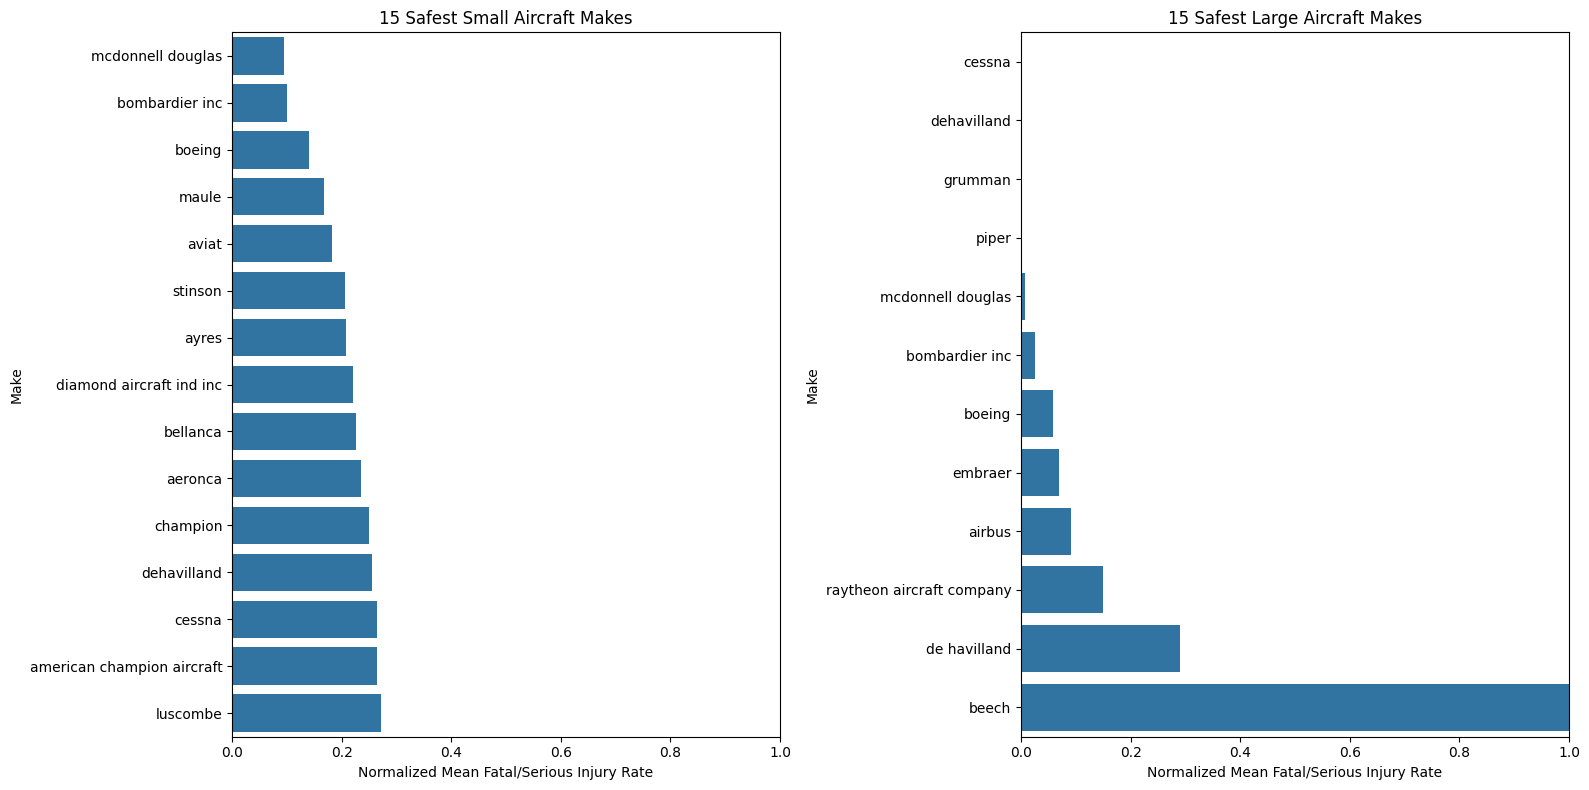

In [5]:
small_fatality_rate = small_plane_df.groupby("Make").mean("Fatal.Serious.Rate").sort_values(by="Fatal.Serious.Rate", ascending=True).head(15)
large_fatality_rate = large_plane_df.groupby("Make").mean("Fatal.Serious.Rate").sort_values(by="Fatal.Serious.Rate", ascending=True).head(15)

max_rate = max(
    small_fatality_rate["Fatal.Serious.Rate"].max(),
    large_fatality_rate["Fatal.Serious.Rate"].max()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

sns.barplot(
    x=small_fatality_rate["Fatal.Serious.Rate"].values,
    y=small_fatality_rate.index,
    ax=axes[0]
)

axes[0].set_title("15 Safest Small Aircraft Makes")
axes[0].set_xlabel("Normalized Mean Fatal/Serious Injury Rate")
axes[0].set_xlim(0, max_rate)
axes[0].set_ylabel("Make")

# Large aircraft chart
sns.barplot(
    x=large_fatality_rate["Fatal.Serious.Rate"].values,
    y=large_fatality_rate.index,
    ax=axes[1]
)

axes[1].set_title("15 Safest Large Aircraft Makes")
axes[1].set_xlabel("Normalized Mean Fatal/Serious Injury Rate")
axes[1].set_xlim(0, max_rate)
axes[1].set_ylabel("Make")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

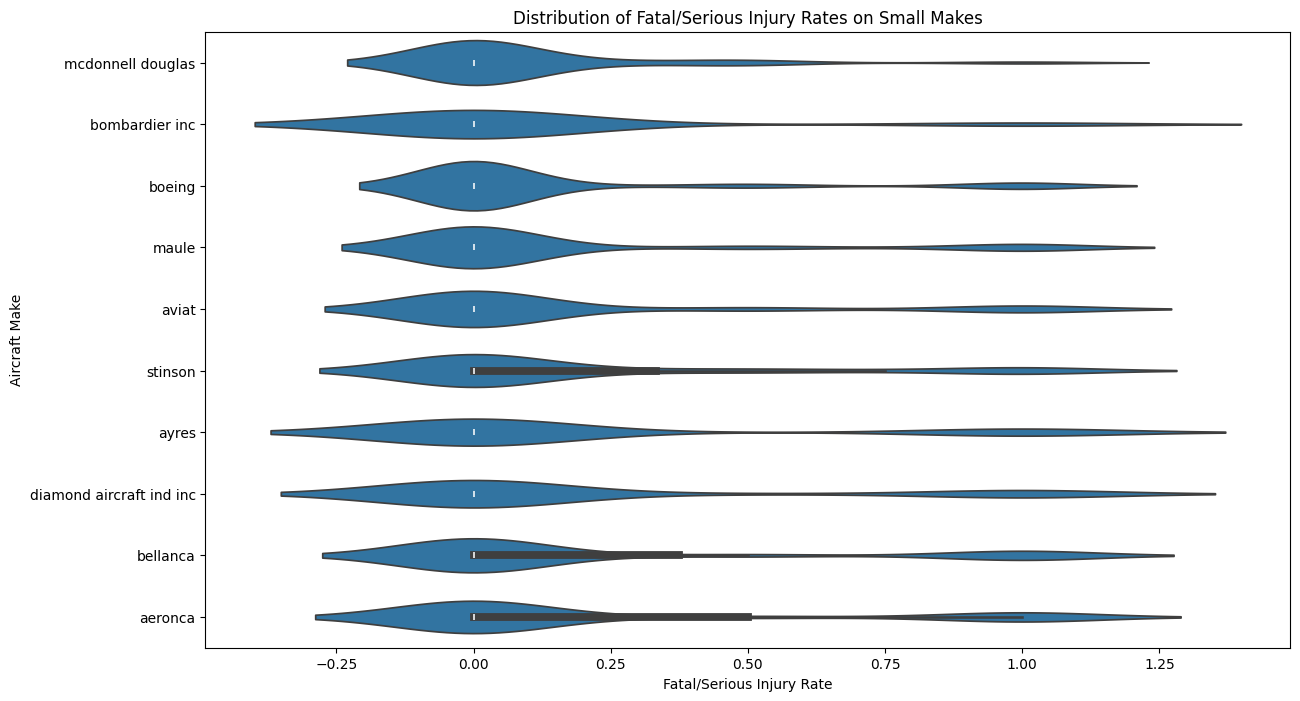

In [6]:
lowest_fatality_small_makes = small_plane_df.groupby("Make").mean("Fatal.Serious.Rate").sort_values(by="Fatal.Serious.Rate", ascending=True).head(10).index

filtered_small_df = small_plane_df[small_plane_df["Make"].isin(lowest_fatality_small_makes)].reset_index(drop=True)

plt.figure(figsize=(14, 8))

sns.violinplot(
    data=filtered_small_df,
    x="Fatal.Serious.Rate",
    y="Make",
    order=lowest_fatality_small_makes,
)

plt.title("Distribution of Fatal/Serious Injury Rates on Small Makes")
plt.xlabel("Fatal/Serious Injury Rate")
plt.ylabel("Aircraft Make")

plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

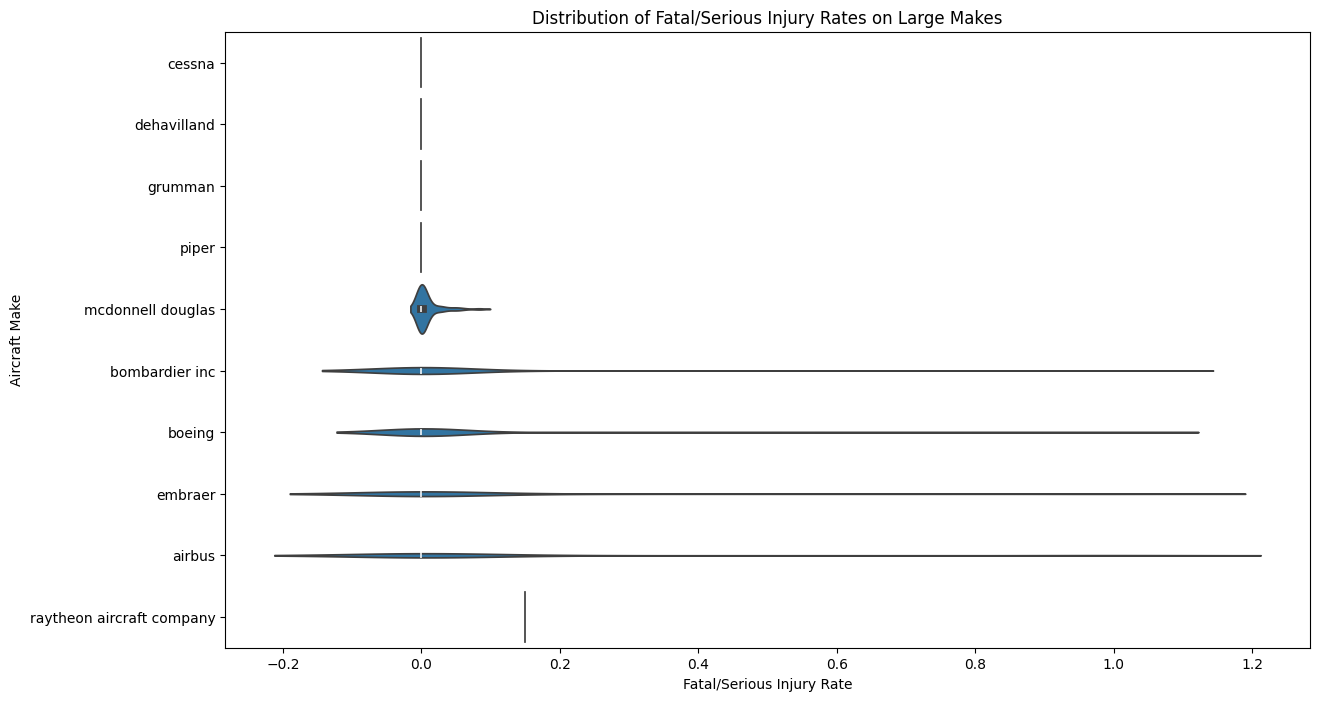

In [7]:
lowest_fatality_large_makes = large_plane_df.groupby("Make").mean("Fatal.Serious.Rate").sort_values(by="Fatal.Serious.Rate", ascending=True).head(10).index

filtered_large_df = large_plane_df[large_plane_df["Make"].isin(lowest_fatality_large_makes)].reset_index(drop=True)

plt.figure(figsize=(14, 8))

sns.violinplot(
    data=filtered_large_df,
    x="Fatal.Serious.Rate",
    y="Make",
    order=lowest_fatality_large_makes
)

plt.title("Distribution of Fatal/Serious Injury Rates on Large Makes")
plt.xlabel("Fatal/Serious Injury Rate")
plt.ylabel("Aircraft Make")

plt.show()

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [8]:
all_fatality_rate = aviation_df.groupby("Make").mean("Fatal.Serious.Rate").sort_values(by="Fatal.Serious.Rate", ascending=True).head(15)
all_fatality_rate

,Number.of.Engines,Total.Fatal.Injuries,Total.Serious.Injuries,Total.Minor.Injuries,Total.Uninjured,Total.Onboard,Fatal.Serious.Count,Fatal.Serious.Rate,Aircraft.Damage
Make,,,,,,,,,
mcdonnell douglas,2.277778,0.268519,0.444444,3.009259,75.925926,79.028037,0.710280,0.039383,0.074766
bombardier inc,1.984127,0.846154,0.230769,0.184615,37.061538,38.365079,0.968254,0.039850,0.031746
boeing,2.045455,2.561807,1.022187,0.358162,70.132330,73.895116,3.617294,0.085268,0.042434
airbus,2.025157,5.415638,0.716049,0.283951,78.473251,81.551282,6.346154,0.112601,0.051282
maule,1.000000,0.162791,0.139535,0.097674,1.223256,1.631579,0.306220,0.167145,0.043062
aviat,1.000000,0.102740,0.198630,0.095890,1.047945,1.437956,0.299270,0.182482,0.065693
stinson,1.000000,0.054264,0.341085,0.170543,1.162791,1.760331,0.388430,0.205923,0.024793
ayres,1.000000,0.127273,0.090909,0.127273,0.672727,1.018519,0.222222,0.207547,0.148148
diamond aircraft ind inc,1.069444,0.216216,0.162162,0.148649,1.148649,1.691176,0.367647,0.220588,0.058824


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [ ]:
# If we want to go by lowest fatality rates among small and large the top 5 safest Makes are
# mcdonnel douglas, bombardier inc, boeings, airbus, and maule

# Based on the graphs of small planes the safest small Make planes are
# mcdonnel douglas, bombardier inc, boeing, maule, and aviat

# For large Makes it is
# cessna, dehavilland, grumman, piper, mcdonnel douglas

# Based on the graphs there doesn't seem to be a ton of data for some of the data points
# For example Beech has a 1.0 fatality rate. There's a few more in the data frames that have 1.0
# They don't show up on the graph because we picked the lowest fatality rates but a few also have 0.0
# Which is also not very consistent. It shows a bit of a data issue that could be resolved but I've
# already spent a lot of time on this

,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,Injury.Severity,Aircraft.damage,...,Total.Uninjured,Weather.Condition,Report.Status,Publication.Date,Total.Onboard,Fatal.Serious.Count,Fatal.Serious.Rate,Aircraft.Damage,Make_Model,Make.Model
Investigation.Type,,,,,,,,,,,,,,,,,,,,,
Accident,DCA08RA053,2008-05-02,"Rumbek, South Sudan",South Sudan,NaN,NaN,NaN,NaN,Fatal,Destroyed,...,0.0,NaN,NaN,25-09-2020,20.0,20.0,1.0,1.0,beech-1900c,beech-1900c
Accident,DCA11WA008,2010-11-05,"Karachi, Pakistan",Pakistan,NaN,NaN,KHI,Karachi-Jinnah International,Fatal,Destroyed,...,0.0,NaN,NaN,03-11-2020,21.0,21.0,1.0,1.0,beech-1900,beech-1900


### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Larger planes**

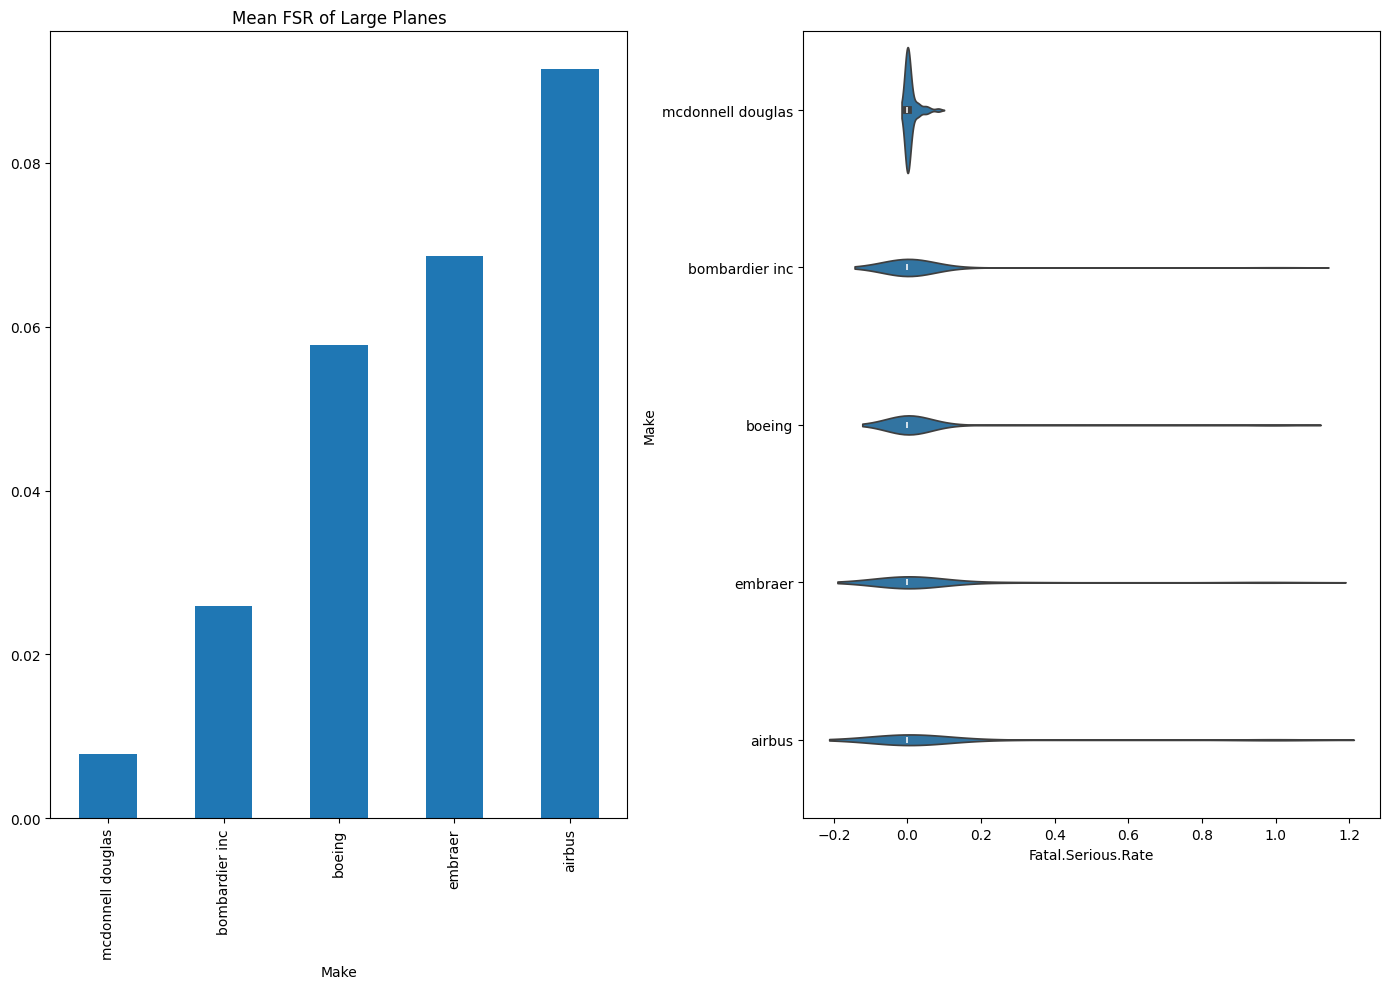

In [27]:
large_counts = large_plane_df.groupby("Make")["Fatal.Serious.Rate"].count()
large_with_10 = large_plane_df[large_plane_df["Make"].isin(large_counts[large_counts >= 10].index)]

large_means = large_with_10.groupby("Make")["Fatal.Serious.Rate"].mean().sort_values().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

large_means.plot.bar(ax=axes[0], title="Mean FSR of Large Planes")
sns.violinplot(data=large_with_10, y="Make", x="Fatal.Serious.Rate", ax=axes[1], order=large_means.index)
plt.tight_layout()

**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

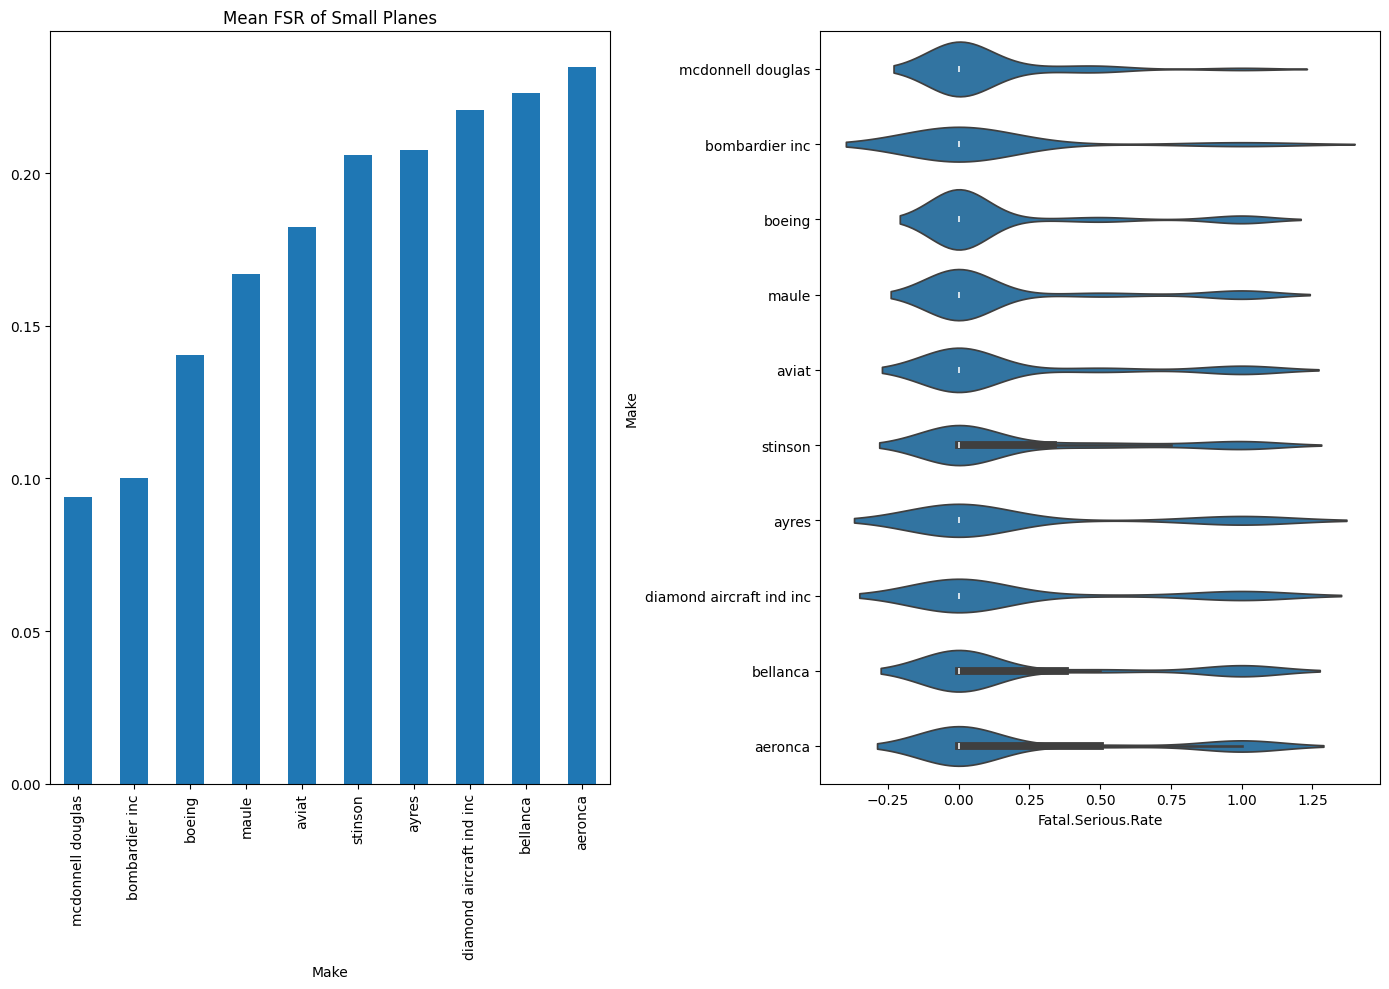

In [29]:
small_counts = small_plane_df.groupby("Make")["Fatal.Serious.Rate"].count()
small_with_10 = small_plane_df[small_plane_df["Make"].isin(small_counts[small_counts >= 10].index)].reset_index(drop=True)

small_means = small_with_10.groupby("Make")["Fatal.Serious.Rate"].mean().sort_values().head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 10))

small_means.plot.bar(ax=axes[0], title="Mean FSR of Small Planes")
sns.violinplot(data=small_with_10, y="Make", x="Fatal.Serious.Rate", ax=axes[1], order=small_means.index)
plt.tight_layout()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [ ]:
# It seems that large aircraft are safer in general but have less data

# Overall the small aircraft had higher means of Fatality Serious Rates(FSR) while large planes had lower means
# But again there was less data for the larger makes with > 10 accidents.

# What suprises me is how common it is for a plane to have an accident where the majority of passengers survive
# I wouldn't expect that for a vehicle flying so fast thousands of feet in the air

# The FSR of small planes being higher doesn't suprise me much as most large Makes probably have professional pilots

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

<Axes: xlabel='Fatal.Serious.Rate', ylabel='Engine.Type'>

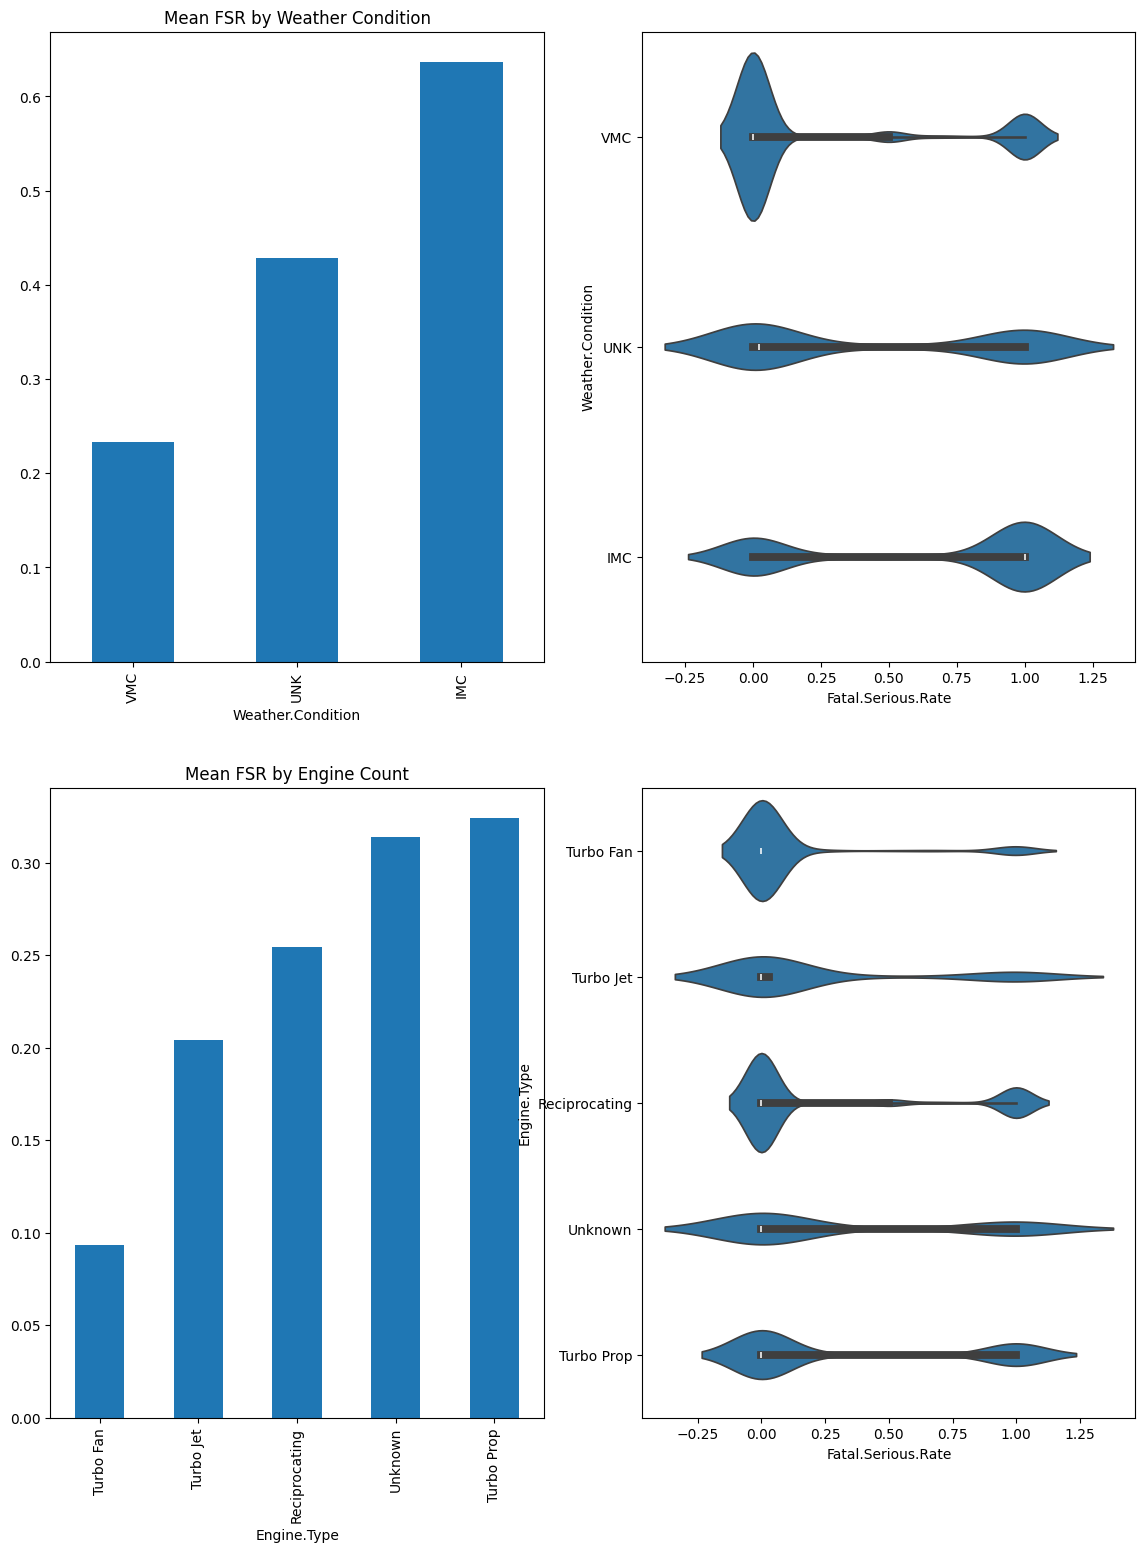

In [ ]:
av = aviation_df.reset_index(drop=True)

weather_means = av.groupby("Weather.Condition")["Fatal.Serious.Rate"].mean().sort_values()
weather_counts = av.groupby("Weather.Condition")["Fatal.Serious.Rate"].count()

engine_counts = av.groupby("Engine.Type")["Fatal.Serious.Rate"].count()
valid_engines = engine_counts[engine_counts >= 10].index
engine_df = av[av["Engine.Type"].isin(valid_engines)]
engine_means = engine_df.groupby("Engine.Type")["Fatal.Serious.Rate"].mean().sort_values()

fig, axes = plt.subplots(2, 2, figsize=(14,18))

weather_means.plot.bar(ax=axes[0,0], title="Mean FSR by Weather Condition")
sns.violinplot(data=av, y="Weather.Condition", x="Fatal.Serious.Rate", ax=axes[0,1], order=weather_means.index)

engine_means.plot.bar(ax=axes[1,0], title="Mean FSR by Engine Type")
sns.violinplot(data=engine_df, y="Engine.Type", x="Fatal.Serious.Rate", ax=axes[1,1], order=engine_means.index)


# No suprise the highest FSR is in IMC weather which is fog, low-clouds, etc.
# Next is unknown conditions which makes sense but also shows a lack of data that could be fixed
# In another version of this

# For engines I expected a mean distribution but it appears there is a difference in engine type and FSR
# I don't know much about engines but I'd assume this is caused by some engines having more problems than others